In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

In [5]:
df = pd.read_csv("Mall_Customers.csv")

In [6]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [7]:
df.shape

(200, 5)

In [8]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [16]:
X = df.iloc[:,[3,4]].values

In [18]:
print(X)

[[ 15  39]
 [ 15  81]
 [ 16   6]
 [ 16  77]
 [ 17  40]
 [ 17  76]
 [ 18   6]
 [ 18  94]
 [ 19   3]
 [ 19  72]
 [ 19  14]
 [ 19  99]
 [ 20  15]
 [ 20  77]
 [ 20  13]
 [ 20  79]
 [ 21  35]
 [ 21  66]
 [ 23  29]
 [ 23  98]
 [ 24  35]
 [ 24  73]
 [ 25   5]
 [ 25  73]
 [ 28  14]
 [ 28  82]
 [ 28  32]
 [ 28  61]
 [ 29  31]
 [ 29  87]
 [ 30   4]
 [ 30  73]
 [ 33   4]
 [ 33  92]
 [ 33  14]
 [ 33  81]
 [ 34  17]
 [ 34  73]
 [ 37  26]
 [ 37  75]
 [ 38  35]
 [ 38  92]
 [ 39  36]
 [ 39  61]
 [ 39  28]
 [ 39  65]
 [ 40  55]
 [ 40  47]
 [ 40  42]
 [ 40  42]
 [ 42  52]
 [ 42  60]
 [ 43  54]
 [ 43  60]
 [ 43  45]
 [ 43  41]
 [ 44  50]
 [ 44  46]
 [ 46  51]
 [ 46  46]
 [ 46  56]
 [ 46  55]
 [ 47  52]
 [ 47  59]
 [ 48  51]
 [ 48  59]
 [ 48  50]
 [ 48  48]
 [ 48  59]
 [ 48  47]
 [ 49  55]
 [ 49  42]
 [ 50  49]
 [ 50  56]
 [ 54  47]
 [ 54  54]
 [ 54  53]
 [ 54  48]
 [ 54  52]
 [ 54  42]
 [ 54  51]
 [ 54  55]
 [ 54  41]
 [ 54  44]
 [ 54  57]
 [ 54  46]
 [ 57  58]
 [ 57  55]
 [ 58  60]
 [ 58  46]
 [ 59  55]

In [19]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters= i ,init="k-means++",random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
    

In [20]:
wcss

[269981.27999999997,
 183653.32894736843,
 106348.37306211118,
 73880.64496247197,
 44448.45544793371,
 40825.16946386946,
 33642.579220779226,
 26686.83778518779,
 24766.47160979344,
 23103.122085983916]

In [33]:
sns.set()

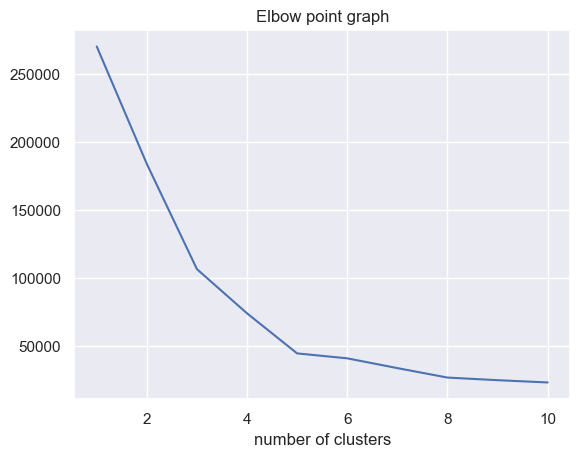

In [34]:
plt.plot(range(1,11), wcss)
plt.title("Elbow point graph")
plt.xlabel("number of clusters")
plt.show()

In [35]:
optimum_clusters = 5
kmeans = KMeans(n_clusters=optimum_clusters , init="k-means++" )

In [36]:
Y = kmeans.fit_predict(X)
print(Y)

[4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4
 0 4 0 4 0 4 2 4 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 3 1 3 2 3 1 3 1 3 2 3 1 3 1 3 1 3 1 3 2 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1
 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3]


In [37]:
kmeans.cluster_centers_

array([[25.72727273, 79.36363636],
       [88.2       , 17.11428571],
       [55.2962963 , 49.51851852],
       [86.53846154, 82.12820513],
       [26.30434783, 20.91304348]])

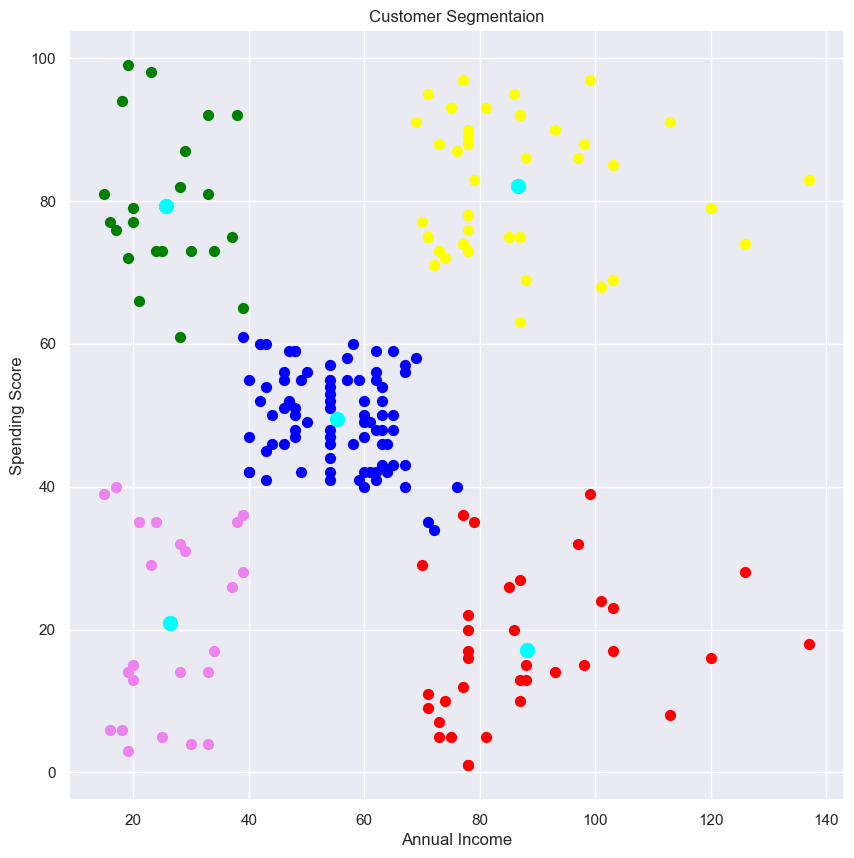

In [38]:
plt.figure(figsize=(10,10))
plt.scatter(X[Y==0,0], X[Y==0,1], s=50, c='green', label ="CLuster 1")
plt.scatter(X[Y==1,0], X[Y==1,1], s=50, c='red', label ="CLuster 2")
plt.scatter(X[Y==2,0], X[Y==2,1], s=50, c='blue', label ="CLuster 3")
plt.scatter(X[Y==3,0], X[Y==3,1], s=50, c='yellow', label ="CLuster 4")
plt.scatter(X[Y==4,0], X[Y==4,1], s=50, c='violet', label ="CLuster 5")

plt.scatter(kmeans.cluster_centers_[:,0] , kmeans.cluster_centers_[:,1], c='cyan', s=100 , label='Centroids')
plt.title("Customer Segmentaion")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.show()


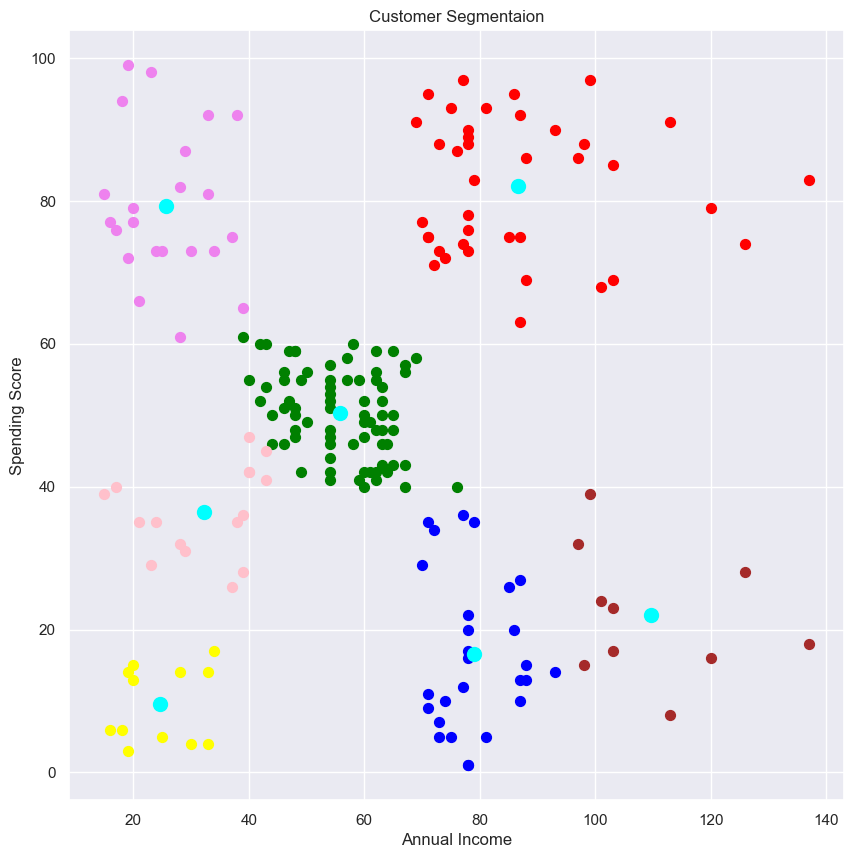

In [32]:
kmeans = KMeans(n_clusters=7 , init="k-means++" )
Y = kmeans.fit_predict(X)
plt.figure(figsize=(10,10))
plt.scatter(X[Y==0,0], X[Y==0,1], s=50, c='green', label ="CLuster 1")
plt.scatter(X[Y==1,0], X[Y==1,1], s=50, c='red', label ="CLuster 2")
plt.scatter(X[Y==2,0], X[Y==2,1], s=50, c='blue', label ="CLuster 3")
plt.scatter(X[Y==3,0], X[Y==3,1], s=50, c='yellow', label ="CLuster 4")
plt.scatter(X[Y==4,0], X[Y==4,1], s=50, c='violet', label ="CLuster 5")
plt.scatter(X[Y==5,0], X[Y==5,1], s=50, c='brown', label ="CLuster 6")
plt.scatter(X[Y==6,0], X[Y==6,1], s=50, c='pink', label ="CLuster 7")

plt.scatter(kmeans.cluster_centers_[:,0] , kmeans.cluster_centers_[:,1], c='cyan', s=100 , label='Centroids')
plt.title("Customer Segmentaion")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.show()